<a href="https://colab.research.google.com/github/ha22756/ha22756/blob/main/hanan1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.io import loadmat


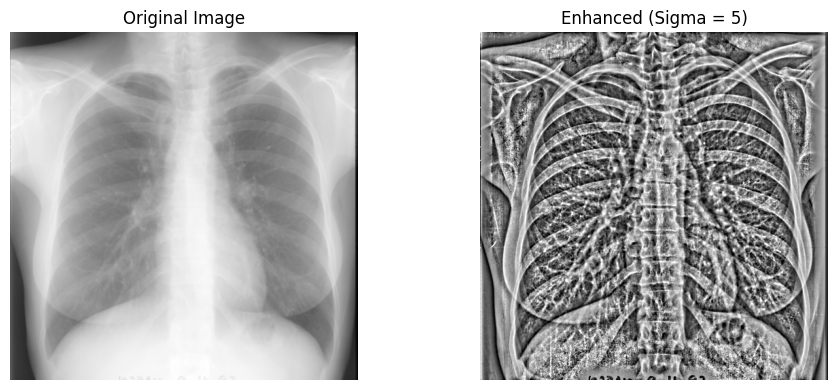

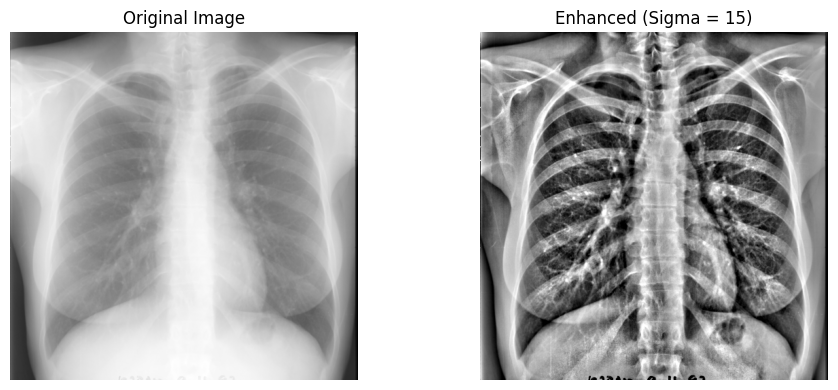

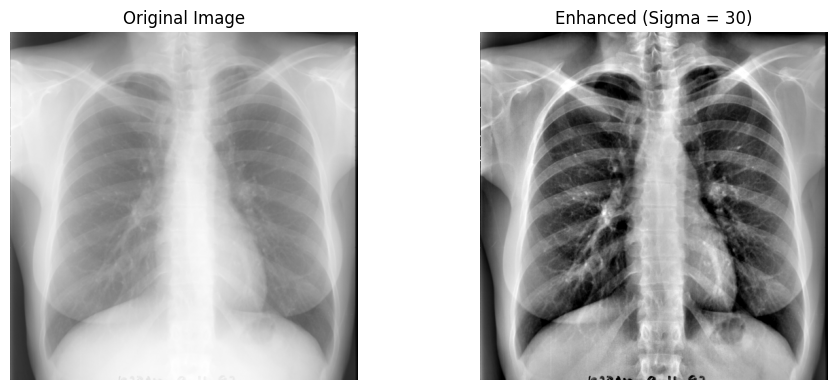

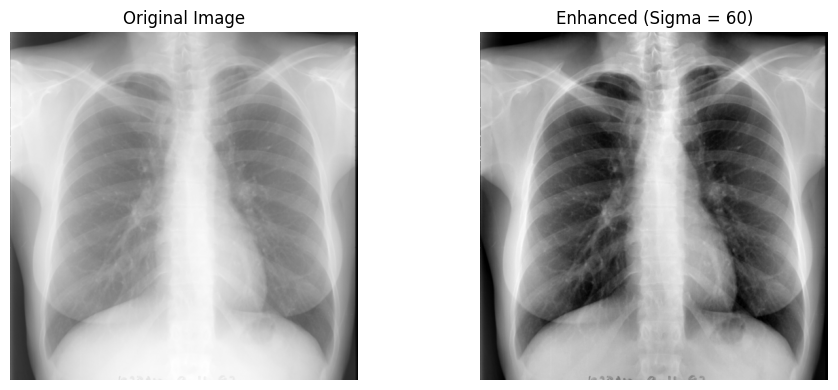

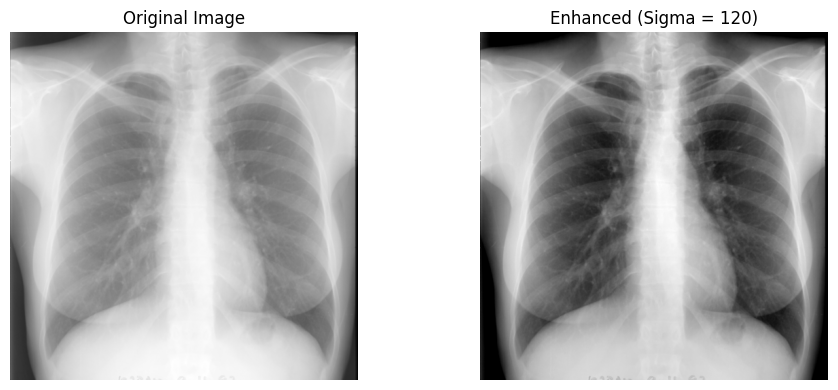


Sigma      | Variance     | Std Dev    | Entropy    | Edge Strength  
--------------------------------------------------------------------------------
5          | 3304.31      | 57.48      | 7.80       | 194.91         
15         | 3319.16      | 57.61      | 7.78       | 88.00          
30         | 3435.33      | 58.61      | 7.76       | 50.85          
60         | 3529.58      | 59.41      | 7.69       | 31.76          
120        | 3614.74      | 60.12      | 7.58       | 25.80          


In [9]:
import numpy as np
from scipy.ndimage import gaussian_filter, sobel
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage.measure import shannon_entropy
import os

# 1. تحميل ملف MAT
url = "https://github.com/ha22756/images/raw/refs/heads/main/JPCNN001_small.mat"
file_name = "JPCNN001_small.mat"

if not os.path.exists(file_name):
    os.system(f"wget {url} -O {file_name}")

# 2. استخراج الصورة
data = loadmat(file_name)
image = data['jrst']['cxr'][0][0]

def local_contrast(image, gauss_std=15):
    image = image.astype(np.float64)
    local_mean = gaussian_filter(image, sigma=gauss_std)
    low_pass = image - local_mean
    variance = gaussian_filter(low_pass ** 2, sigma=gauss_std)
    std_dev = np.sqrt(variance)
    std_dev[std_dev == 0] = np.mean(std_dev[std_dev != 0])

    enhanced_image = 64 * (low_pass / std_dev) + 127
    enhanced_image = np.clip(enhanced_image, 0, 255)
    return enhanced_image.astype(np.uint8)

def calculate_edge_strength(img):
    """
    دالة لحساب قوة الحافة باستخدام مرشح سوبل
    """
    # حساب التدرج في الاتجاهين الأفقي والعمودي
    sx = sobel(img.astype(np.float64), axis=0, mode='constant')
    sy = sobel(img.astype(np.float64), axis=1, mode='constant')
    # حساب مقدار التدرج (Gradient Magnitude)
    magnitude = np.hypot(sx, sy)
    # إرجاع متوسط قوة الحواف
    return np.mean(magnitude)

# قائمة لتخزين النتائج النهائية
results_list = []

# 3. تنفيذ 5 تجارب
sigmas = [5, 15, 30, 60, 120]

for s in sigmas:
    enhanced = local_contrast(image, gauss_std=s)

    # حساب المقاييس
    v_val = np.var(enhanced)                             # التباين
    s_val = np.std(enhanced)                             # الانحراف المعياري
    e_val = shannon_entropy(enhanced)                    # الإنتروبيا
    edge_val = calculate_edge_strength(enhanced)         # قوة الحافة

    # حفظ النتائج في القائمة
    results_list.append((s, v_val, s_val, e_val, edge_val))

    # عرض الصور
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Enhanced (Sigma = {s})")
    plt.imshow(enhanced, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- الآن عرض النتائج المحسوبة كلها في قائمة واحدة بالأسفل ---
print("\n" + "="*80)
print(f"{'Sigma':<10} | {'Variance':<12} | {'Std Dev':<10} | {'Entropy':<10} | {'Edge Strength':<15}")
print("-" * 80)

for res in results_list:
    s, v, sd, e, edge = res
    print(f"{s:<10} | {v:<12.2f} | {sd:<10.2f} | {e:<10.2f} | {edge:<15.2f}")
print("="*80)